Recommandation de film par similarité utilisateurs

In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

# 1. Données

In [7]:
rating = pd.read_csv("./data/ml-100k/u.data", sep='\t', names=['userID', 'movieID', 'rating', 'timestamp'])
rating.head()

,userID,movieID,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [166]:
movies = pd.read_csv("./data/ml-100k/u.item", sep="|", encoding="latin-1",
                     names=["movieID", "title", "releaseDate", "videoReleaseDate", "IMDbURL", "genreUnknow", "genreAction", "genreAdventure", "genreAnimation", "genreChildren", "genreComedy", "genreCrime", "genreDocumentary", "genreDrama", "genreFantasy", "genreFilmNoir", "genreHorror", "genreMusical", "genreMystery", "genreRomance", "genreSciFi", "genreThriller", "genreWar", "genreWestern"],
                    )
movies.head()

,movieID,title,releaseDate,videoReleaseDate,IMDbURL,genreUnknow,genreAction,genreAdventure,genreAnimation,genreChildren,...,genreFantasy,genreFilmNoir,genreHorror,genreMusical,genreMystery,genreRomance,genreSciFi,genreThriller,genreWar,genreWestern
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


# 2. Preprocessing

In [23]:
rating.shape

(100000, 4)

In [21]:
rating.isna().sum(axis=0)

userID       0
movieID      0
rating       0
timestamp    0
dtype: int64

In [22]:
movies.shape

(1682, 24)

In [19]:
movies.isna().sum(axis=0)

movieId                0
title                  0
releaseDate            1
videoReleaseDate    1682
IMDbURL                3
genreUnknow            0
genreAction            0
genreAdventure         0
genreAnimation         0
genreChildren          0
genreComedy            0
genreCrime             0
genreDocumentary       0
genreDrama             0
genreFantasy           0
genreFilmNoir          0
genreHorror            0
genreMusical           0
genreMystery           0
genreRomance           0
genreSciFi             0
genreThriller          0
genreWar               0
genreWestern           0
dtype: int64

In [167]:
movies.drop(['videoReleaseDate'], axis=1, inplace=True)

In [168]:
movies.dropna(axis=0, inplace=True)

In [169]:
movies.isna().sum(axis=0)

movieID             0
title               0
releaseDate         0
IMDbURL             0
genreUnknow         0
genreAction         0
genreAdventure      0
genreAnimation      0
genreChildren       0
genreComedy         0
genreCrime          0
genreDocumentary    0
genreDrama          0
genreFantasy        0
genreFilmNoir       0
genreHorror         0
genreMusical        0
genreMystery        0
genreRomance        0
genreSciFi          0
genreThriller       0
genreWar            0
genreWestern        0
dtype: int64

In [38]:
rating.duplicated().sum(axis=0)

np.int64(0)

In [170]:
movies.duplicated().sum(axis=0)

np.int64(0)

# 3. plot data

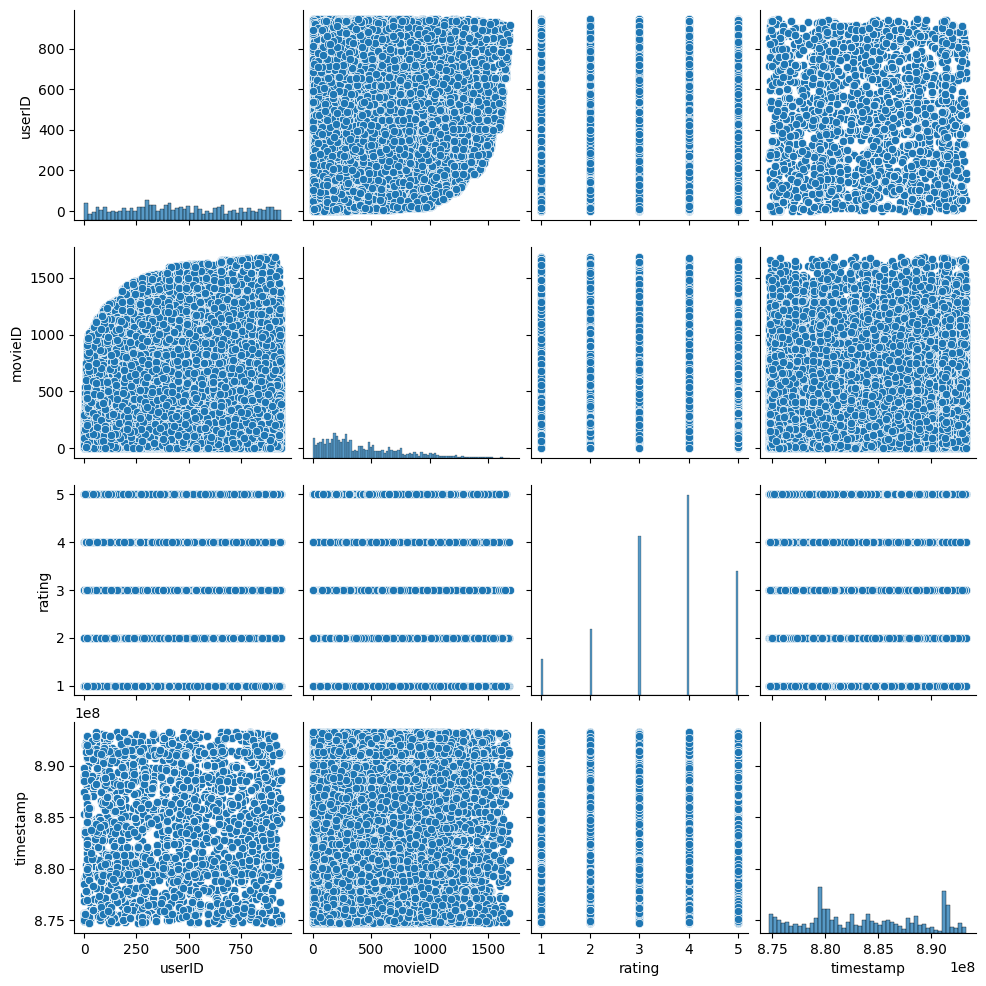

In [45]:
sns.pairplot(data=rating)

In [80]:
rating.groupby('userID').value_counts()

userID  movieID  rating  timestamp
1       46       4       876893230    1
        257      4       874965954    1
        12       5       878542960    1
        74       1       889751736    1
        134      4       875073067    1
                                     ..
943     217      3       888640067    1
        94       4       888639929    1
        943      5       888639614    1
        566      4       888639886    1
        2        5       888639953    1
Name: count, Length: 100000, dtype: int64

In [81]:
rating[rating['userID']==1].shape

(272, 4)

In [171]:
movies.info()

<class 'pandas.DataFrame'>
Index: 1679 entries, 0 to 1681
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   movieID           1679 non-null   int64
 1   title             1679 non-null   str  
 2   releaseDate       1679 non-null   str  
 3   IMDbURL           1679 non-null   str  
 4   genreUnknow       1679 non-null   int64
 5   genreAction       1679 non-null   int64
 6   genreAdventure    1679 non-null   int64
 7   genreAnimation    1679 non-null   int64
 8   genreChildren     1679 non-null   int64
 9   genreComedy       1679 non-null   int64
 10  genreCrime        1679 non-null   int64
 11  genreDocumentary  1679 non-null   int64
 12  genreDrama        1679 non-null   int64
 13  genreFantasy      1679 non-null   int64
 14  genreFilmNoir     1679 non-null   int64
 15  genreHorror       1679 non-null   int64
 16  genreMusical      1679 non-null   int64
 17  genreMystery      1679 non-null   int64
 18  genr

In [172]:
movies_cols_num = movies.select_dtypes(include=['number'])
movies_cols_num.shape

(1679, 20)

In [174]:
movies_cols_num.head()

,movieID,genreUnknow,genreAction,genreAdventure,genreAnimation,genreChildren,genreComedy,genreCrime,genreDocumentary,genreDrama,genreFantasy,genreFilmNoir,genreHorror,genreMusical,genreMystery,genreRomance,genreSciFi,genreThriller,genreWar,genreWestern
0,1,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
3,4,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0
4,5,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0


In [93]:
rating.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   userID     100000 non-null  int64
 1   movieID    100000 non-null  int64
 2   rating     100000 non-null  int64
 3   timestamp  100000 non-null  int64
dtypes: int64(4)
memory usage: 3.1 MB


In [131]:
rating.head()

,userID,movieID,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [126]:
rating_mean = rating.groupby('movieID')['rating'].mean().reset_index()
rating_mean

,movieID,rating
0,1,3.878319
1,2,3.206107
2,3,3.033333
3,4,3.550239
4,5,3.302326
...,...,...
1677,1678,1.000000
1678,1679,3.000000
1679,1680,2.000000
1680,1681,3.000000


In [137]:
rating_withe_mean = rating.join(rating_mean, on='movieID', how='left', rsuffix='_mean')
rating_withe_mean.drop(columns=['movieID_mean'], inplace=True)

In [143]:
rating_mean[rating_mean['movieID']==1682]

,movieID,rating
1681,1682,3.0


In [ ]:
rating_withe_mean[rating_withe_mean['rating_mean'].isna()]
rating_withe_mean.fillna(3.0, inplace=True)

,userID,movieID,rating,timestamp,rating_mean
0,196,242,3,881250949,2.439394
1,186,302,3,891717742,3.686567
2,22,377,1,878887116,3.722772
3,244,51,2,880606923,3.769231
4,166,346,1,886397596,3.510949
...,...,...,...,...,...
99995,880,476,3,880175444,3.210526
99996,716,204,5,879795543,3.992647
99997,276,1090,1,874795795,2.720930
99998,13,225,2,882399156,3.355422


In [148]:
rating_withe_mean.isna().sum()

userID         0
movieID        0
rating         0
timestamp      0
rating_mean    0
dtype: int64

In [158]:
movies.columns

Index(['movieID', 'title', 'releaseDate', 'IMDbURL', 'genreUnknow',
       'genreAction', 'genreAdventure', 'genreAnimation', 'genreChildren',
       'genreComedy', 'genreCrime', 'genreDocumentary', 'genreDrama',
       'genreFantasy', 'genreFilmNoir', 'genreHorror', 'genreMusical',
       'genreMystery', 'genreRomance', 'genreSciFi', 'genreThriller',
       'genreWar', 'genreWestern'],
      dtype='str')

In [175]:
#rating mean in movie table
movies_with_mean_rating = movies_cols_num.join(rating_mean, on='movieID', how='left', rsuffix='_mean')
movies_with_mean_rating.drop(columns=['movieID_mean'], inplace=True)
movies_with_mean_rating.head()

,movieID,genreUnknow,genreAction,genreAdventure,genreAnimation,genreChildren,genreComedy,genreCrime,genreDocumentary,genreDrama,...,genreFilmNoir,genreHorror,genreMusical,genreMystery,genreRomance,genreSciFi,genreThriller,genreWar,genreWestern,rating
0,1,0,0,0,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,3.206107
1,2,0,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,3.033333
2,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,3.550239
3,4,0,1,0,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,3.302326
4,5,0,0,0,0,0,0,1,0,1,...,0,0,0,0,0,0,1,0,0,3.576923


In [179]:
movies_features = movies_with_mean_rating[['movieID', 'genreUnknow',
       'genreAction', 'genreAdventure', 'genreAnimation', 'genreChildren',
       'genreComedy', 'genreCrime', 'genreDocumentary', 'genreDrama',
       'genreFantasy', 'genreFilmNoir', 'genreHorror', 'genreMusical',
       'genreMystery', 'genreRomance', 'genreSciFi', 'genreThriller',
       'genreWar', 'genreWestern']]
movies_target = movies_with_mean_rating[['rating']]

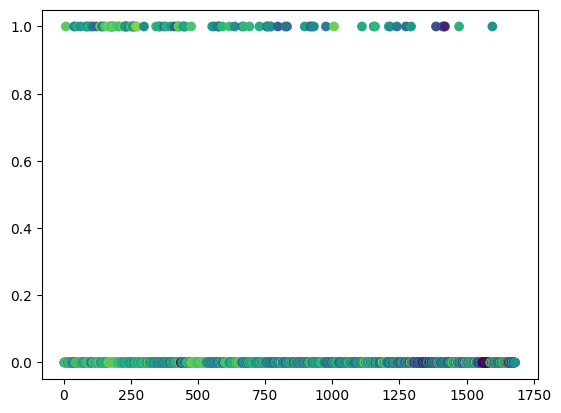

In [181]:
plt.scatter(data=movies_with_mean_rating, x='movieID', y='genreSciFi', c='rating')

# 4. Training model

In [186]:
movies_target.fillna(3.0, inplace=True)

,rating
0,3.206107
1,3.033333
2,3.550239
3,3.302326
4,3.576923
...,...
1677,3.000000
1678,2.000000
1679,3.000000
1680,3.000000


In [188]:
x_train, x_test, y_train, y_test = train_test_split(movies_features, movies_target, test_size=0.2)

In [190]:
model = KNeighborsClassifier(n_neighbors=5)
model.fit(movies_features, movies_target)

/home/fallou/mlpro/module_3/.venv/lib/python3.13/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


ValueError: Unknown label type: continuous. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.